# Optimal test statistic: the Neyman-Pearson lemma

* The likelihood ratio is the optimal test statistic: for a given test of $H_0$ of size $\alpha$ it gives the highest power with respect to the alternative $H_1$
$$ t(x) = \frac{P(x|H_1)}{P(x|H_0)} $$

N.B. any monotonic function of $t(x)$ leads to the same test

* Demonstration of the NP lemma can be found in text books

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define two 2D distributions (Hypotheses)

# H0: Centered at (0, 0)
mean0 = [0, 0]
cov0 = [[1, 0.5], [0.5, 1]]

# H1: Centered at (2, 2)
mean1 = [2, 2]
cov1 = [[1, -0.5], [-0.5, 1]]

rv0 = multivariate_normal(mean0, cov0)
rv1 = multivariate_normal(mean1, cov1)

# Generate 500 random samples from each distribution
n_samples = 500
np.random.seed(42)
samples0 = rv0.rvs(n_samples)
samples1 = rv1.rvs(n_samples)

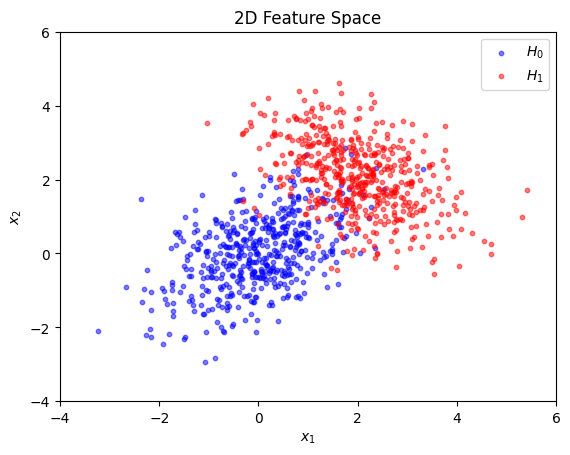

In [2]:
plt.scatter(samples0[:, 0], samples0[:, 1], alpha=0.5, label='$H_0$', color='blue', s=10)
plt.scatter(samples1[:, 0], samples1[:, 1], alpha=0.5, label='$H_1$', color='red', s=10)
plt.title('2D Feature Space')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.xlim(-4, 6)
plt.ylim(-4, 6)
plt.legend()
plt.show()
#@title { vertical-output: true}

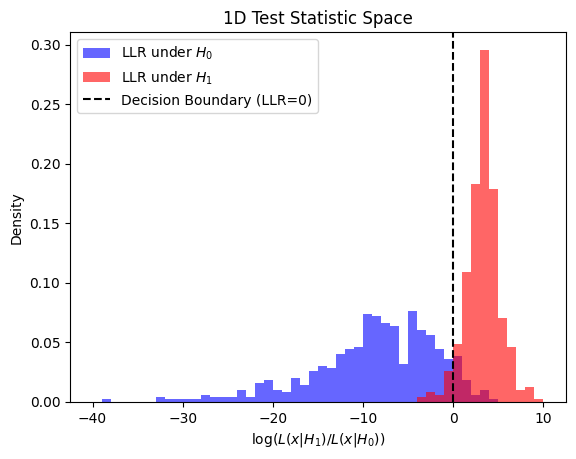

In [3]:
# Calculate the Log-Likelihood Ratio (LLR) for each point
# LLR(x) = log( P(x|H1) / P(x|H0) )
llr_samples0 = rv1.logpdf(samples0) - rv0.logpdf(samples0)
llr_samples1 = rv1.logpdf(samples1) - rv0.logpdf(samples1)

# Plot the 1D Test Statistic Space (Log-Likelihood Ratio)
plt.hist(llr_samples0, bins=50, alpha=0.6, range=(-40, 10),
         label='LLR under $H_0$', color='blue', density=True)
plt.hist(llr_samples1, bins=50, alpha=0.6, range=(-40, 10),
         label='LLR under $H_1$', color='red', density=True)
plt.axvline(x=0, color='black', linestyle='--', label='Decision Boundary (LLR=0)')
plt.title('1D Test Statistic Space')
plt.xlabel(r'$\log(L(x|H_1) / L(x|H_0))$')
plt.ylabel('Density')
plt.legend()
plt.show()
#@title { vertical-output: true}

the place of the boundary is decided by the alpha value: if alpha is 5%, you can then take the graph up here and watch where 5% falls.

There is no correlation between 0 in the graph and 5% of the alpha

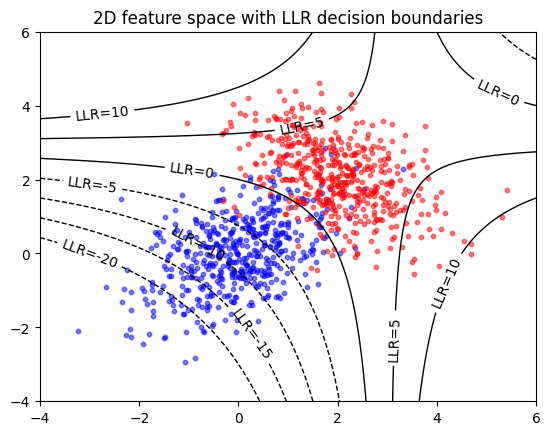

In [4]:
# 3. Create a grid to evaluate LLR for contours
x_min, x_max, y_min, y_max = -4, 6, -4, 6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
pos = np.dstack((xx, yy))
llr_grid = rv1.logpdf(pos) - rv0.logpdf(pos)

#4. Plotting
plt.scatter(samples0[:, 0], samples0[:, 1], alpha=0.5, label='$H_0$', color='blue', s=10)
plt.scatter(samples1[:, 0], samples1[:, 1], alpha=0.5, label='$H_1$', color='red', s=10)

# Plot LLR contour lines
levels = np.arange(-20, 11, 5)
contours = plt.contour(xx, yy, llr_grid, levels=levels, colors='black', linewidths=1)
plt.clabel(contours, inline=True, fontsize=10, fmt='LLR=%.0f')
plt.title('2D feature space with LLR decision boundaries')
plt.xlim(-4,6)
plt.ylim(-4, 6)
plt.show()
#@title { vertical-output: true}